# trajkit × Geolife — visual validation

Runs the full trajkit pipeline on one Geolife user, then visualises the
results so you can judge whether the segmentation, episode detection,
and similarity search produce sensible output on real-world GPS.

The notebook walks the discretization hierarchy from the bottom up:
**pings → segments → episodes**. Each level has a "what it is" cell,
an "anatomy of one example" cell, and a map view. Episode similarity at
the end is the headline query — "find me trips like this trip" —
rendered as the actual constituent segment paths, not straight lines.

## Setup

In [1]:
from pathlib import Path
import os
import sys
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

import folium
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Local Geolife reader
sys.path.insert(0, str(Path.cwd()))
sys.path.insert(0, "examples/geolife")
from reader import read_user  # noqa: E402

from trajkit.compare import build_index, search  # noqa: E402
from trajkit.runner import RunParams, process  # noqa: E402
from trajkit.segment import segment as run_segment  # noqa: E402

GEOLIFE_DATA = Path(os.path.expanduser("~/.cache/trajkit/Geolife Trajectories 1.3/Data"))
USER_ID = "000"
TIME_WINDOW_DAYS = 7

## 1. Load Geolife user

In [2]:
all_pings = read_user(GEOLIFE_DATA / USER_ID, entity_id=USER_ID)
print(f"User {USER_ID}: {len(all_pings):,} pings spanning "
      f"{all_pings['ts'].min().date()} → {all_pings['ts'].max().date()}")

day_counts = all_pings["ts"].dt.floor("D").value_counts().sort_values(ascending=False)
busiest_day = day_counts.index[0]
window_start = busiest_day - pd.Timedelta(days=TIME_WINDOW_DAYS // 2)
window_end = window_start + pd.Timedelta(days=TIME_WINDOW_DAYS)
mask = (all_pings["ts"] >= window_start) & (all_pings["ts"] < window_end)
pings = all_pings.loc[mask].reset_index(drop=True)
print(f"Window: {window_start.date()} → {window_end.date()}  "
      f"({len(pings):,} pings)")

User 000: 173,870 pings spanning 2008-10-23 → 2009-07-05
Window: 2009-03-31 → 2009-04-07  (23,603 pings)


## 2. Run the trajkit pipeline (pedestrian preset)

In [3]:
sink = Path("/tmp/trajkit_geolife_explore")
if sink.exists():
    import shutil
    shutil.rmtree(sink)
params = RunParams.from_preset("pedestrian")
report = process(pings, sink, params, n_workers=1)
print(f"succeeded={report.succeeded}  elapsed={report.elapsed_seconds:.1f}s")

succeeded=True  elapsed=0.5s


## 3. Read pipeline outputs

The runner persists per-segment aggregated frames (one row per segment),
not the per-ping intermediate. To draw real ping paths in this notebook
we re-run the per-ping segmentation locally on the cleaned frame.

In [4]:
cleaned_per_ping = pd.read_parquet(
    sink / "clean" / f"entity_id={USER_ID}" / "data.parquet"
)
cleaned_per_ping["entity_id"] = cleaned_per_ping["entity_id"].astype("string")
# Also restore entity_id from the Hive path (the column is stripped on Hive write)
if cleaned_per_ping["entity_id"].isna().any() or len(cleaned_per_ping["entity_id"].unique()) == 0:
    cleaned_per_ping["entity_id"] = pd.Series([USER_ID] * len(cleaned_per_ping), dtype="string")
per_ping_segmented = run_segment(cleaned_per_ping, params.segment)

segments = pd.read_parquet(
    sink / "segment" / f"entity_id={USER_ID}" / "data.parquet"
)
episodes = pd.read_parquet(
    sink / "episode" / f"entity_id={USER_ID}" / "data.parquet"
)
seg_vectors_df = pd.read_parquet(
    sink / "embed_segments" / f"entity_id={USER_ID}" / "data.parquet"
)
ep_vectors_df = pd.read_parquet(
    sink / "embed_episodes" / f"entity_id={USER_ID}" / "data.parquet"
)
print(f"Pings (cleaned):       {len(per_ping_segmented):>7,}")
print(f"Segments (aggregated): {len(segments):>7,}")
print(f"Episodes:              {len(episodes):>7,} "
      f"(STAY={(episodes['episode_type']=='STAY').sum()}, "
      f"TRANSIT={(episodes['episode_type']=='TRANSIT').sum()})")

Pings (cleaned):        23,603
Segments (aggregated):     800
Episodes:                  157 (STAY=83, TRANSIT=74)


## 4. Pings → Segments → Episodes

trajkit's discretization is a **three-level hierarchy**. Each level
describes the data at a different scale, with stricter membership
rules than the level below.

**Ping** — one GPS observation. Just `(entity_id, ts, lat, lon, ...)`.
Raw input. No semantic interpretation.

**Segment** — a contiguous run of pings classified into one
*behavioural type*: `MOVE`, `MOVE_BRIEF`, `STOP_BRIEF`, or
`STOP_DWELL`. The hysteresis state machine in `trajkit.segment`
decides where one segment ends and the next begins. A segment answers:
*"what kind of motion was happening here?"* It's the smallest typed
unit — one stop at a red light, one stretch of highway, one yard
manoeuvre.

**Episode** — a contiguous run of segments classified into one of two
*operational types*: `STAY` (the entity was *here*) or `TRANSIT` (the
entity was *going somewhere*). The spatial-envelope rule in
`trajkit.episode` groups segments by location, with a grace window for
brief excursions. An episode answers: *"what was the entity doing?"*
It's the unit a human would use to talk about the day.

**Membership rules in plain English:**

* Each ping belongs to exactly one segment, decided by the hysteresis
  state machine + sustained-bearing splits.
* Each segment belongs to exactly one episode. Pass 1 of the episode
  detector greedily grows STAYs by accepting consecutive segments
  whose endpoints stay within radius `R_m` of the running anchor
  centroid; brief excursions outside the envelope (≤ `T_s` seconds of
  accumulated outside time) are absorbed into the stay. Pass 2: every
  maximal run of unclaimed segments becomes a TRANSIT, split where the
  inter-segment gap exceeds `T_s`.

Let's look at one real example from this user's data.

In [5]:
# Show one episode's nested structure
sample_ep = episodes[episodes["episode_type"] == "TRANSIT"].sort_values(
    "n_segments", ascending=False
).iloc[0]
print(
    f"Episode {sample_ep['episode_id']}  "
    f"({sample_ep['episode_type']}, {sample_ep['duration_s']:.0f}s, "
    f"{int(sample_ep['n_segments'])} segments, "
    f"{float(sample_ep['path_length_m']):.0f}m path)"
)
print()
print("├── segments (one per row, time-ordered):")
for seg_id in sample_ep["segment_ids"]:
    seg = segments.loc[segments["segment_id"] == seg_id].iloc[0]
    n_pings = (per_ping_segmented["segment_id"] == seg_id).sum()
    print(
        f"│   ├── {seg_id}  "
        f"{seg['segment_type']:<11s}  {seg['duration_s']:>5.0f}s  "
        f"path={seg['path_length_m']:>6.0f}m  pings={n_pings}"
    )
print("│")
print("└── (each segment in turn is a contiguous run of pings)")

Episode ep_000_00126  (TRANSIT, 8110s, 17 segments, 5212m path)

├── segments (one per row, time-ordered):
│   ├── 000_seg_00699  MOVE           645s  path=  2110m  pings=134
│   ├── 000_seg_00700  STOP_BRIEF      40s  path=    10m  pings=11
│   ├── 000_seg_00701  MOVE           330s  path=   554m  pings=69
│   ├── 000_seg_00702  STOP_BRIEF     105s  path=    10m  pings=23
│   ├── 000_seg_00703  MOVE           120s  path=    47m  pings=7
│   ├── 000_seg_00704  STOP_BRIEF      50s  path=     5m  pings=12
│   ├── 000_seg_00705  MOVE_BRIEF      10s  path=    12m  pings=3
│   ├── 000_seg_00706  STOP_BRIEF      35s  path=     8m  pings=10
│   ├── 000_seg_00707  MOVE          4310s  path=   171m  pings=29
│   ├── 000_seg_00708  STOP_BRIEF      45s  path=     7m  pings=11
│   ├── 000_seg_00709  MOVE           675s  path=  1257m  pings=136
│   ├── 000_seg_00710  STOP_BRIEF      85s  path=    13m  pings=21
│   ├── 000_seg_00711  MOVE          1040s  path=   827m  pings=211
│   ├── 000_seg_00712

**Reading guide.** This TRANSIT episode is a single journey, but
inside it there are several distinct typed segments — perhaps a
`MOVE`, a `STOP_BRIEF` at a traffic light, another `MOVE`. Each
segment is itself a run of dozens of pings. The hierarchy is what
makes downstream queries possible: ping-level data is too granular
to ask "what kind of trip is this?", segment-level is too noisy
(one trip = many segments), episode-level is the right grain.

## 5. Segment-type breakdown

Atomic count + total duration share per segment type.

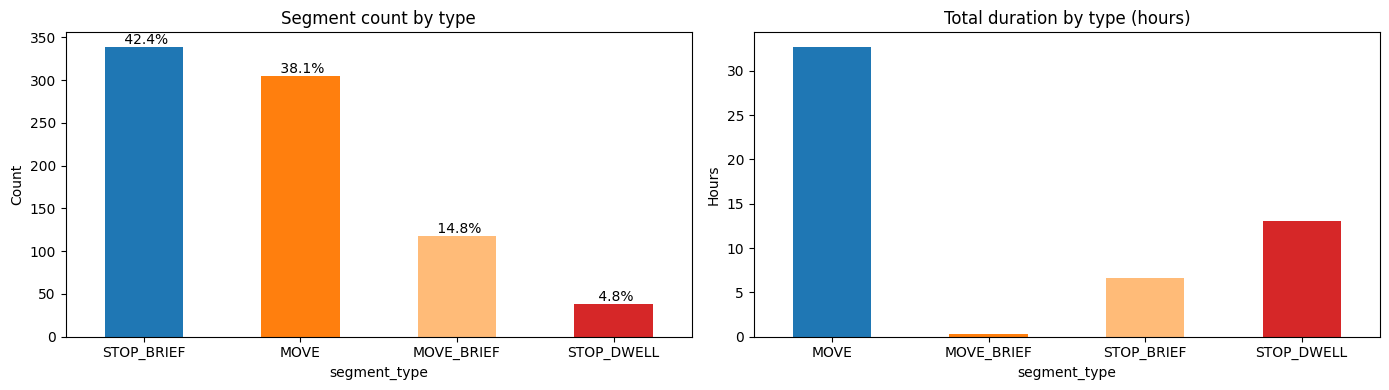

In [6]:
type_counts = segments["segment_type"].value_counts()
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
type_counts.plot.bar(ax=ax[0], color=["#1f77b4", "#ff7f0e", "#ffbb78", "#d62728"])
ax[0].set_title("Segment count by type")
ax[0].set_ylabel("Count")
ax[0].tick_params(axis="x", rotation=0)
fractions = (type_counts / type_counts.sum() * 100).round(1)
for i in range(len(type_counts)):
    ax[0].text(i, type_counts.iloc[i], f" {fractions.iloc[i]}%", ha="center", va="bottom")
type_total_duration = segments.groupby("segment_type")["duration_s"].sum() / 3600
type_total_duration.plot.bar(ax=ax[1], color=["#1f77b4", "#ff7f0e", "#ffbb78", "#d62728"])
ax[1].set_title("Total duration by type (hours)")
ax[1].set_ylabel("Hours")
ax[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 6. Map: segments along the actual ping path

Each polyline traces the **actual GPS pings** of one segment. Colour
encodes `segment_type`. Hover for type + duration + ping count. Note
that segments respect the natural shape of the trajectory — they're
*runs of consecutive pings*, not synthetic straight lines.

In [7]:
COLOUR = {
    "MOVE": "#1f77b4",
    "MOVE_BRIEF": "#ff7f0e",
    "STOP_BRIEF": "#ffbb78",
    "STOP_DWELL": "#d62728",
}

center_lat = float(pings["lat"].median())
center_lon = float(pings["lon"].median())
m_segments = folium.Map(
    location=[center_lat, center_lon], zoom_start=12, tiles="cartodbpositron"
)

# Group pings by segment_id, draw each group as a polyline through its pings.
seg_meta = segments.set_index("segment_id")[["segment_type", "duration_s"]]
for seg_id, group in per_ping_segmented.groupby("segment_id", sort=False):
    if len(group) < 2:
        continue
    if seg_id not in seg_meta.index:
        continue
    meta = seg_meta.loc[seg_id]
    seg_type = str(meta["segment_type"])
    coords = list(zip(group["lat"].astype(float), group["lon"].astype(float), strict=True))
    folium.PolyLine(
        locations=coords,
        color=COLOUR.get(seg_type, "#888888"),
        weight=3 if seg_type.startswith("MOVE") else 5,
        opacity=0.6,
        tooltip=(
            f"{seg_id} • {seg_type} • {float(meta['duration_s']):.0f}s • "
            f"pings={len(group)}"
        ),
    ).add_to(m_segments)

legend_html = """
<div style='position: fixed; top:10px; right:10px; z-index:9999;
            background:white; padding:8px; border:1px solid #888; font-size:13px;'>
  <b>Segment type</b><br>
  <span style='color:#1f77b4'>━━━</span> MOVE<br>
  <span style='color:#ff7f0e'>━━━</span> MOVE_BRIEF<br>
  <span style='color:#ffbb78'>━━━</span> STOP_BRIEF<br>
  <span style='color:#d62728'>━━━</span> STOP_DWELL<br>
</div>
"""
m_segments.get_root().html.add_child(folium.Element(legend_html))
m_segments.save("segments_map.html")
m_segments

## 7. Anatomy of one segment

Zoom into a single MOVE segment and look at the pings that make it up.
A segment is *not* a straight line from start to end — it's a
sequence of GPS observations sharing a common motion type. The
straight-line displacement (`displacement_m`) is the bird's-eye gap
between the first and last ping; the actual `path_length_m` is the
sum of inter-ping displacements along the way.

In [8]:
# Pick a MOVE segment with a representative ping count
move_segments = segments[segments["segment_type"] == "MOVE"].copy()
move_segments["__ping_count"] = move_segments["segment_id"].map(
    per_ping_segmented["segment_id"].value_counts()
)
sample_seg = move_segments.sort_values("__ping_count", ascending=False).iloc[
    len(move_segments) // 4  # pick around the 25th-percentile-from-largest
]
sample_pings = per_ping_segmented[
    per_ping_segmented["segment_id"] == sample_seg["segment_id"]
].sort_values("ts")
print(
    f"Segment: {sample_seg['segment_id']} ({sample_seg['segment_type']})"
)
print(f"  pings:                 {len(sample_pings)}")
print(f"  duration_s:            {sample_seg['duration_s']:.1f}")
print(f"  start → end straight:  {sample_seg['displacement_m']:.1f} m")
print(f"  actual path length:    {sample_seg['path_length_m']:.1f} m")
print(f"  straightness:          {sample_seg['straightness']:.3f}  "
      f"(displacement / path_length)")

# Map zoomed to this segment
seg_center_lat = float(sample_pings["lat"].mean())
seg_center_lon = float(sample_pings["lon"].mean())
m_one_seg = folium.Map(
    location=[seg_center_lat, seg_center_lon], zoom_start=15, tiles="cartodbpositron"
)
# Actual ping path
folium.PolyLine(
    locations=list(zip(sample_pings["lat"].astype(float),
                       sample_pings["lon"].astype(float),
                       strict=True)),
    color=COLOUR[str(sample_seg["segment_type"])],
    weight=4,
    opacity=0.8,
    tooltip=f"actual path: {sample_seg['path_length_m']:.0f}m through "
             f"{len(sample_pings)} pings",
).add_to(m_one_seg)
# Straight-line displacement (dashed grey, for comparison)
folium.PolyLine(
    locations=[(float(sample_seg["start_lat"]), float(sample_seg["start_lon"])),
               (float(sample_seg["end_lat"]), float(sample_seg["end_lon"]))],
    color="#666666", weight=2, opacity=0.6, dash_array="6,6",
    tooltip=f"start → end straight line: {sample_seg['displacement_m']:.0f}m",
).add_to(m_one_seg)
# Markers
folium.CircleMarker(
    location=[float(sample_seg["start_lat"]), float(sample_seg["start_lon"])],
    radius=6, color="#2ca02c", fill=True, fill_opacity=0.9,
    tooltip="segment start",
).add_to(m_one_seg)
folium.CircleMarker(
    location=[float(sample_seg["end_lat"]), float(sample_seg["end_lon"])],
    radius=6, color="#9467bd", fill=True, fill_opacity=0.9,
    tooltip="segment end",
).add_to(m_one_seg)
m_one_seg.save("segment_anatomy.html")
m_one_seg

Segment: 000_seg_00272 (MOVE)
  pings:                 59
  duration_s:            260.0
  start → end straight:  36.2 m
  actual path length:    187.5 m
  straightness:          0.193  (displacement / path_length)


**Reading guide.** The coloured polyline is the segment's actual
pings. The grey dashed line is what you'd see in a "straight line"
rendering. The ratio `path_length / displacement` is `1 / straightness`
in our schema — it's how curvy the trajectory is. A straight commute
down a single road has straightness ≈ 1.0; a winding park walk is
closer to 0.3.

## 8. Stay duration distribution

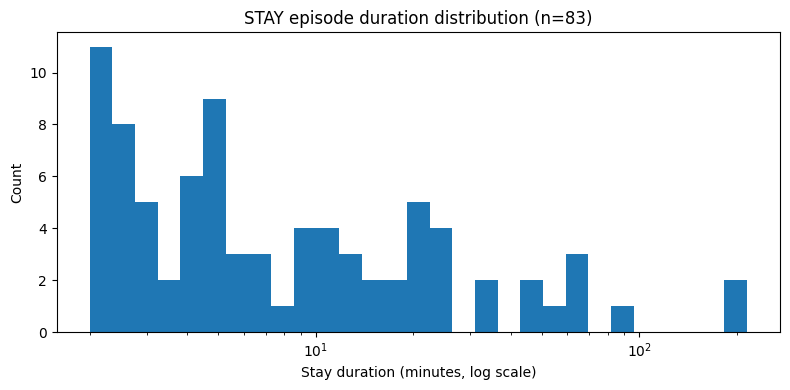

In [9]:
stay_minutes = episodes.loc[episodes["episode_type"] == "STAY", "duration_s"] / 60.0
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.hist(stay_minutes, bins=np.logspace(np.log10(2), np.log10(stay_minutes.max() + 1), 30))
ax.set_xscale("log")
ax.set_xlabel("Stay duration (minutes, log scale)")
ax.set_ylabel("Count")
ax.set_title(f"STAY episode duration distribution (n={len(stay_minutes)})")
plt.tight_layout()
plt.show()

## 9. STAY anchors

In [10]:
stays = episodes[episodes["episode_type"] == "STAY"].copy()
m_stays = folium.Map(
    location=[center_lat, center_lon], zoom_start=12, tiles="cartodbpositron"
)
for _, ep in stays.iterrows():
    duration_min = float(ep["duration_s"]) / 60.0
    radius = float(np.clip(np.log1p(duration_min) * 2.5, 4, 25))
    folium.CircleMarker(
        location=[float(ep["anchor_lat"]), float(ep["anchor_lon"])],
        radius=radius,
        color="#d62728",
        fill=True,
        fill_opacity=0.5,
        tooltip=(
            f"{duration_min:.1f} min • envelope_radius={ep['envelope_radius_m']:.1f} m"
        ),
    ).add_to(m_stays)
m_stays.save("stays_map.html")
m_stays

## 10. Episode-type breakdown

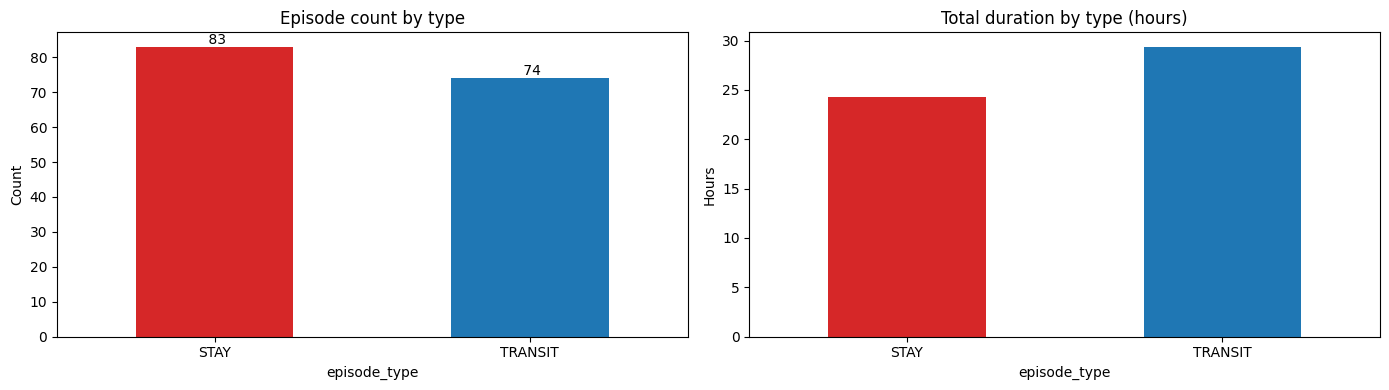

In [11]:
ep_type_counts = episodes["episode_type"].value_counts()
ep_total_duration_h = episodes.groupby("episode_type")["duration_s"].sum() / 3600
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ep_type_counts.plot.bar(ax=ax[0], color=["#d62728", "#1f77b4"])
ax[0].set_title("Episode count by type")
ax[0].set_ylabel("Count")
ax[0].tick_params(axis="x", rotation=0)
for i, count in enumerate(ep_type_counts):
    ax[0].text(i, count, f" {count}", ha="center", va="bottom")
ep_total_duration_h.plot.bar(ax=ax[1], color=["#d62728", "#1f77b4"])
ax[1].set_title("Total duration by type (hours)")
ax[1].set_ylabel("Hours")
ax[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 11. Anatomy of one episode

An episode is built of segments, and each segment is built of pings.
Here we render one TRANSIT with its constituent segments coloured
individually — you can see the boundaries the segmentation chose
(where one MOVE ends and the next begins, where a STOP_BRIEF
interrupts movement) inside one continuous journey.

In [12]:
def _episode_path_polyline(
    fmap: folium.Map,
    episode: pd.Series,
    rank: int = 0,
    is_query: bool = False,
) -> None:
    """Draw an episode's constituent segments through actual pings."""
    seg_ids = list(episode["segment_ids"])
    for sid in seg_ids:
        seg_pings = per_ping_segmented[per_ping_segmented["segment_id"] == sid]
        if len(seg_pings) < 2:
            continue
        seg_meta_row = segments.loc[segments["segment_id"] == sid]
        if len(seg_meta_row) == 0:
            continue
        seg_type = str(seg_meta_row.iloc[0]["segment_type"])
        if is_query:
            colour = "#000000"
            weight = 5.0
            opacity = 0.95
        else:
            colour = COLOUR.get(seg_type, "#1f77b4")
            weight = 3.0
            opacity = float(max(0.35, 0.9 - rank * 0.12))
        folium.PolyLine(
            locations=list(zip(seg_pings["lat"].astype(float),
                               seg_pings["lon"].astype(float),
                               strict=True)),
            color=colour,
            weight=weight,
            opacity=opacity,
            tooltip=(
                f"ep={episode['episode_id']} rank={rank} "
                f"seg={sid} {seg_type}"
            ),
        ).add_to(fmap)


sample_transit = episodes[episodes["episode_type"] == "TRANSIT"].sort_values(
    "n_segments", ascending=False
).iloc[0]
print(
    f"Episode {sample_transit['episode_id']}  "
    f"({sample_transit['episode_type']}, {sample_transit['duration_s']:.0f}s, "
    f"{int(sample_transit['n_segments'])} segments, "
    f"{float(sample_transit['path_length_m']):.0f}m path)"
)
seg_type_in_ep = []
for sid in sample_transit["segment_ids"]:
    s = segments.loc[segments["segment_id"] == sid].iloc[0]
    seg_type_in_ep.append(s["segment_type"])
print("  Segment-type composition:",
      pd.Series(seg_type_in_ep).value_counts().to_dict())

# Centre on this episode
ep_pings_subset = per_ping_segmented[
    per_ping_segmented["segment_id"].isin(sample_transit["segment_ids"])
]
ep_center_lat = float(ep_pings_subset["lat"].mean())
ep_center_lon = float(ep_pings_subset["lon"].mean())

m_one_ep = folium.Map(
    location=[ep_center_lat, ep_center_lon], zoom_start=14, tiles="cartodbpositron"
)
_episode_path_polyline(m_one_ep, sample_transit, rank=0, is_query=False)
folium.CircleMarker(
    location=[float(sample_transit["start_lat"]), float(sample_transit["start_lon"])],
    radius=7, color="#2ca02c", fill=True, fill_opacity=0.9,
    tooltip="episode start",
).add_to(m_one_ep)
folium.CircleMarker(
    location=[float(sample_transit["end_lat"]), float(sample_transit["end_lon"])],
    radius=7, color="#9467bd", fill=True, fill_opacity=0.9,
    tooltip="episode end",
).add_to(m_one_ep)
m_one_ep.get_root().html.add_child(folium.Element(legend_html))
m_one_ep.save("episode_anatomy.html")
m_one_ep

Episode ep_000_00126  (TRANSIT, 8110s, 17 segments, 5212m path)
  Segment-type composition: {'MOVE': 7, 'STOP_BRIEF': 7, 'MOVE_BRIEF': 2, 'STOP_DWELL': 1}


**Reading guide.** Each colour change along the journey is a segment
boundary. Look for: stretches of blue (`MOVE`) interrupted by short
yellow blocks (`STOP_BRIEF` at a traffic light), or orange chunks
(`MOVE_BRIEF`, e.g. parking lot manoeuvring before reaching the road).
This is what segmentation is *for* — turning a continuous journey
into a sequence of typed atomic events.

## 12. TRANSIT map

All TRANSIT episodes drawn as their constituent segments' actual
paths. Different from the segments map in section 6 only in
selection: the segments shown here are exactly those bound into
TRANSIT episodes (i.e., the *journeys*).

In [13]:
m_transits = folium.Map(
    location=[center_lat, center_lon], zoom_start=12, tiles="cartodbpositron"
)
transits = episodes[episodes["episode_type"] == "TRANSIT"]
for _, ep in transits.iterrows():
    _episode_path_polyline(m_transits, ep, rank=0, is_query=False)
m_transits.get_root().html.add_child(folium.Element(legend_html))
m_transits.save("transits_map.html")
m_transits

## 13. Episode-level similarity (with constituent segment paths)

The headline behavioural query: *"find me trips like this trip."*
Pooled `embed_episodes` vectors capture kinematic shape + duration +
n_segments + episode-type. Cosine similarity over those vectors
answers behavioural-similarity, not geographic proximity.

The query is rendered in **black**, the top-5 hits in colour by
segment_type with decreasing opacity by rank.

In [14]:
ep_vectors = np.vstack(
    [np.asarray(v, dtype=np.float32) for v in ep_vectors_df["vector"]]
)
ep_ids = ep_vectors_df["id"].astype(str).tolist()

transit_episodes = episodes[episodes["episode_type"] == "TRANSIT"].sort_values(
    "duration_s"
)
if len(transit_episodes) > 0:
    query_ep_id = transit_episodes["episode_id"].iloc[len(transit_episodes) // 2]
    query_idx = ep_ids.index(query_ep_id)
    ep_index = build_index(ep_vectors, ep_ids, metric="cosine")
    ep_hits = search(ep_index, ep_vectors[query_idx], k=6)
    print(f"Query: {query_ep_id}")
    hits_table = pd.DataFrame(
        [{"rank": h.rank, "episode_id": h.id, "score": h.score} for h in ep_hits]
    )
    hits_table = hits_table.merge(
        episodes[
            ["episode_id", "episode_type", "duration_s", "n_segments",
             "path_length_m", "displacement_m"]
        ],
        on="episode_id",
    )
    print(
        hits_table[
            ["rank", "episode_id", "score", "episode_type", "duration_s",
             "n_segments", "path_length_m"]
        ].round(3).to_string(index=False)
    )

    m_ep_sim = folium.Map(
        location=[center_lat, center_lon], zoom_start=11, tiles="cartodbpositron"
    )
    for _, row in hits_table.iterrows():
        ep_row = episodes.loc[episodes["episode_id"] == row["episode_id"]].iloc[0]
        is_query = row["rank"] == 0
        if ep_row["episode_type"] == "STAY":
            folium.CircleMarker(
                location=[float(ep_row["anchor_lat"]), float(ep_row["anchor_lon"])],
                radius=10 if is_query else 6,
                color="#000000" if is_query else "#1f77b4",
                fill=True,
                fill_opacity=0.7 if is_query else 0.5,
                tooltip=(
                    f"rank={row['rank']} score={row['score']:.4f} STAY "
                    f"({float(ep_row['duration_s']) / 60:.0f} min)"
                ),
            ).add_to(m_ep_sim)
        else:
            _episode_path_polyline(
                m_ep_sim, ep_row, rank=int(row["rank"]), is_query=is_query
            )
    m_ep_sim.save("episode_similarity_map.html")
else:
    print("No TRANSIT episodes — episode similarity demo skipped.")

m_ep_sim if len(transit_episodes) > 0 else None

Query: ep_000_00116
 rank   episode_id  score episode_type  duration_s  n_segments  path_length_m
    0 ep_000_00116  1.000      TRANSIT       600.0           3    1490.688965
    1 ep_000_00014  0.998      TRANSIT      1195.0           3    2726.009033
    2 ep_000_00153  0.997      TRANSIT       496.0           3    1651.025024
    3 ep_000_00128  0.997      TRANSIT       505.0           3    2407.122070
    4 ep_000_00040  0.997      TRANSIT       820.0           3     977.421997
    5 ep_000_00154  0.997      TRANSIT       460.0           3    1109.836060


**Reading guide.** Compare the table to the segment-similarity table
logic from earlier exposition: episode similarity should match on
*behaviour shape* — transits with similar duration + path length +
n_segments. The map shows the actual constituent segment paths of
each hit; if the hits look behaviourally similar (e.g., 5-min walks
of similar distance) but geographically scattered, that's a good
sign — the embedding captured *what* not *where*.

## What we learned

Things to check by eye:

1. Section 6 segments map: do colours track physical activity?
   Long blue (`MOVE`) on streets, red (`STOP_DWELL`) at residential
   locations, orange (`MOVE_BRIEF`) clusters at building entrances?
2. Section 7 single-segment: does the actual path explain why
   `path_length_m > displacement_m`? Is the straightness number
   consistent with how curvy the path looks?
3. Section 9 STAY anchors: do markers cluster at obviously recurring
   places? In Beijing user 000's trace, expect tight clusters at home
   and at work / a campus location.
4. Section 11 single-episode: are the segment boundaries inside the
   journey at sensible places (intersections, parking, transitions)?
5. Section 13 episode similarity: are the top-5 hits behaviourally
   similar (similar duration + n_segments) even when geographically
   scattered?

Each "no" is a tuning lead. Each "yes" is real validation that the
discretization layer is doing its job.